In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

In [40]:
# Load team player and team data from github
url_player = 'https://raw.githubusercontent.com/jpelayo35/CPSC5071_DSP/refs/heads/main/yearly_player_data.csv'
# player = pd.read_csv(url_player, index_col=0)
player = pd.read_csv(url_player)
url_team = 'https://raw.githubusercontent.com/jpelayo35/CPSC5071_DSP/refs/heads/main/yearly_team_data.csv'
team = pd.read_csv(url_team)

In [41]:
# Pick the columns for players that are stat specific to the "Wide Receiver" Position
# Pick the column for team that are offensive statistics related to scoring


In [42]:
col_names_player=['team', 'player_id', 'player_name', 'position', 'season', 'depth', 'pass_attempts', 'targets', 'receptions', 'receiving_yards', 
                  'reception_td','total_tds', 'total_yards', 'height', 'weight', 'college', 'age']
col_names_team=['team', 'season', 'touchdown', 'td_points', 'pass_attempts', 'passing_yards', 'pass_td', 'receptions', 'receiving_yards',
               'receiving_td']

In [43]:
# Filter out the columns based on the previous cell
df_player=player[col_names_player]
df_player=df_player[df_player['position'] == 'WR']
df_team=team[col_names_team]

A lot of these variables were unnecessary because we are only focused on analyzing the "Wide Reciever" position. Thus we filtered out variables based on what may be needed.

In [44]:
average_team=df_team.groupby('team').mean()
average_by_season=df_team.drop(df_team.columns[0], axis=1).groupby('season').mean().reset_index()

#df_team.drop(df_team.columns[0], axis=1, inplace=False)
#average_by_season=df_team.groupby('season').mean()

In [45]:
average_by_season.describe()

,season,touchdown,td_points,pass_attempts,passing_yards,pass_td,receptions,receiving_yards,receiving_td
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,2017.500000,41.651042,249.906250,548.174479,4032.023438,26.953125,357.093750,4030.804688,26.953125
std,3.605551,2.018990,12.113939,10.505819,88.838211,1.296815,12.046902,88.617837,1.296815
min,2012.000000,38.281250,229.687500,531.343750,3833.093750,25.125000,338.531250,3832.875000,25.125000
25%,2014.750000,40.648438,243.890625,541.507812,4005.757812,25.953125,349.226562,4004.468750,25.953125
50%,2017.500000,41.140625,246.843750,548.656250,4032.750000,27.000000,359.171875,4031.609375,27.000000
75%,2020.250000,42.070312,252.421875,556.609375,4080.968750,27.992188,363.835938,4079.781250,27.992188
max,2023.000000,46.031250,276.187500,568.906250,4150.000000,28.625000,378.781250,4148.125000,28.625000


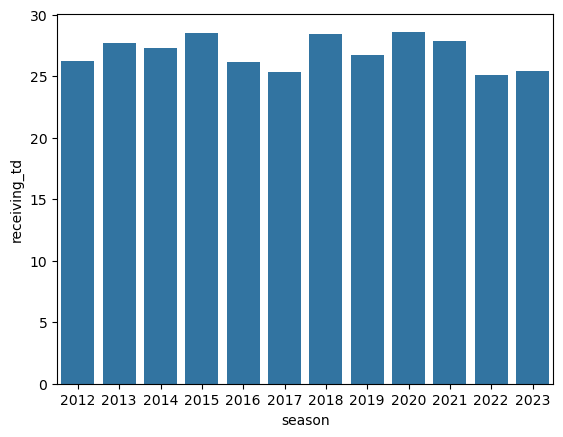

In [46]:
sns.barplot(x = 'season', y = 'receiving_td', data = average_by_season)
plt.show()

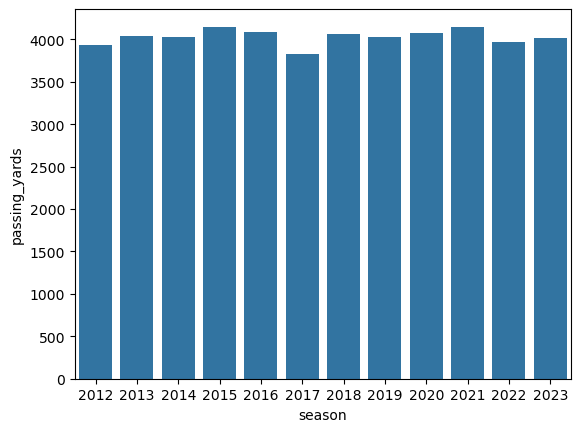

In [47]:
sns.barplot(x = 'season', y = 'passing_yards', data = average_by_season)
plt.show()

Initially, our thoughts were that as the years become more modern, more recieving touchdowns would occur. However, after plotting the touchdowns and the number of passing yards each year, we can see that each season has around 27 TDs and a little under 4000 passing yards (in fact, 2023 even saw a decrease from the previous 3 seasons). Thus we can conclude that the year does not really affect the total number of touchdowns/passing yards. 

In [48]:
df_team

,team,season,touchdown,td_points,pass_attempts,passing_yards,pass_td,receptions,receiving_yards,receiving_td
0,ARI,2012,28,168,586,3383,17,337,3383,17
1,ARI,2013,37,222,551,4291,25,363,4291,25
2,ARI,2014,28,168,556,3990,22,320,3990,22
3,ARI,2015,53,318,543,4775,36,353,4775,36
4,ARI,2016,51,306,626,4425,30,383,4425,30
...,...,...,...,...,...,...,...,...,...,...
379,WAS,2019,31,186,463,3205,21,298,3205,21
380,WAS,2020,35,210,585,3796,17,389,3796,17
381,WAS,2021,38,228,532,3746,23,356,3746,23
382,WAS,2022,35,210,536,3783,26,344,3783,26


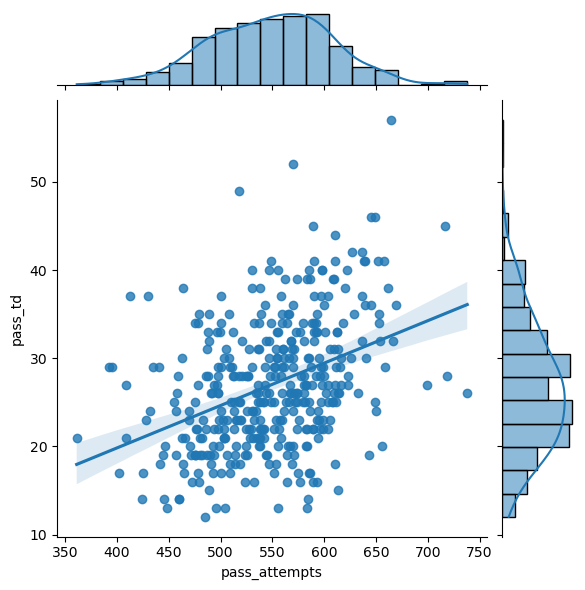

In [49]:
sns.jointplot(data=df_team, x="pass_attempts", y="pass_td", kind='reg')


Based on this chart, we can see that teams that have more pass_attempts affects the ammount of total pass touchdowns that they get. Thus in our final model, we can conclude that players who play for teams that "pass attempt" the ball a lot will score more touchdowns.

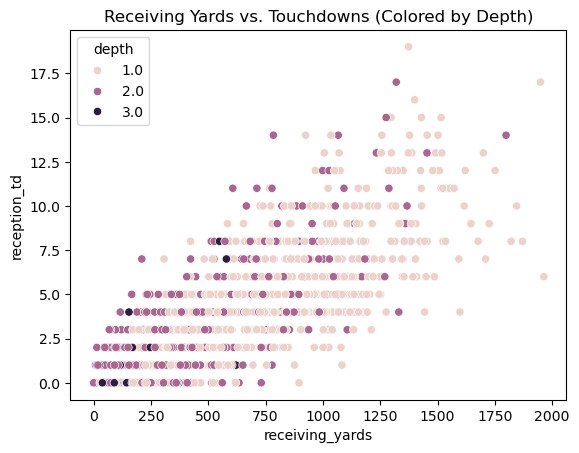

In [50]:
sns.scatterplot(x = 'receiving_yards', y = 'reception_td', hue='depth', data = df_player)
plt.title("Receiving Yards vs. Touchdowns (Colored by Depth)")
plt.show()

Depth is a variable that describes the ranking of the player on the team. For example, if depth is 1 then the player is the #1 option to recieve the ball on the team. We can see that players who are #1 options are more likely to have more receiving yards and reception touchdowns. However, the #2 option can also get a lot of receiving yards. Thus, this may be a good variable to include in a model.

In [51]:
df_player.describe()

,season,depth,pass_attempts,targets,receptions,receiving_yards,reception_td,total_tds,total_yards,height,weight,age
count,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000
mean,2018.049747,1.739291,0.110548,53.418701,32.612621,421.621373,2.687241,2.770152,433.339014,72.562414,200.888991,25.783510
std,3.319307,0.667356,0.450022,46.086217,29.639269,397.700707,3.085019,3.147547,403.851344,2.368991,15.408213,2.991097
min,2012.000000,1.000000,0.000000,0.000000,0.000000,-3.000000,0.000000,0.000000,-11.000000,66.000000,155.000000,20.000000
25%,2015.000000,1.000000,0.000000,14.000000,7.000000,83.000000,0.000000,0.000000,91.000000,71.000000,190.000000,23.500000
50%,2018.000000,2.000000,0.000000,42.000000,24.000000,298.000000,2.000000,2.000000,309.000000,73.000000,200.000000,25.000000
75%,2021.000000,2.000000,0.000000,85.000000,51.000000,666.500000,4.000000,4.000000,685.000000,74.000000,211.000000,28.000000
max,2023.000000,3.000000,10.000000,204.000000,149.000000,1964.000000,19.000000,19.000000,1967.000000,78.000000,310.000000,37.000000


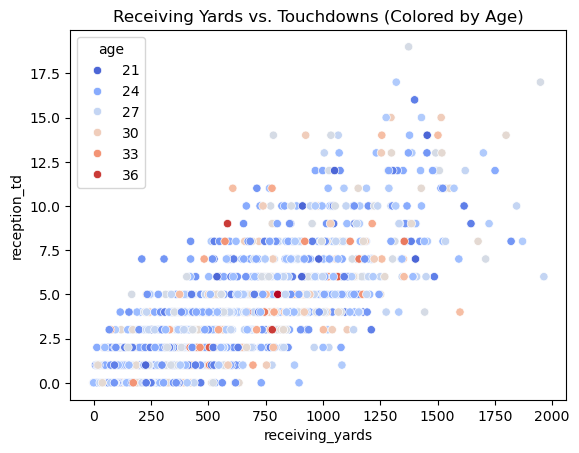

In [52]:
sns.scatterplot(x='receiving_yards', y='reception_td', hue='age', data=df_player, palette='coolwarm')
plt.title("Receiving Yards vs. Touchdowns (Colored by Age)")
plt.show()


This scatterplot, similar to the previous one, shows how receiving TDs are correlated with receiving yards, but this time we can see how age has an influence on these variables. Ages 33+ seem to have a much lower chance of getting 10+ touch downs in a season.

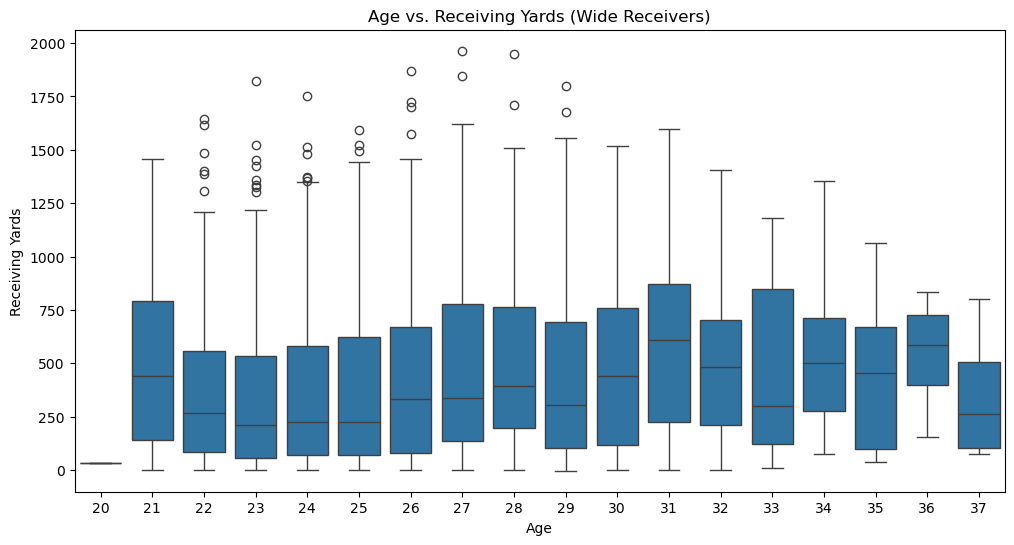

In [53]:
plt.figure(figsize=(12,6))
sns.boxplot(x='age', y='receiving_yards', data=df_player)
plt.title("Age vs. Receiving Yards (Wide Receivers)")
plt.xlabel("Age")
plt.ylabel("Receiving Yards")
plt.show()



Here is a boxplot that shows a different perspective, receiving yards relative to age.

In [64]:
print(df_player['season'].dtype)
print(df_team['season'].dtype)


int32
int32


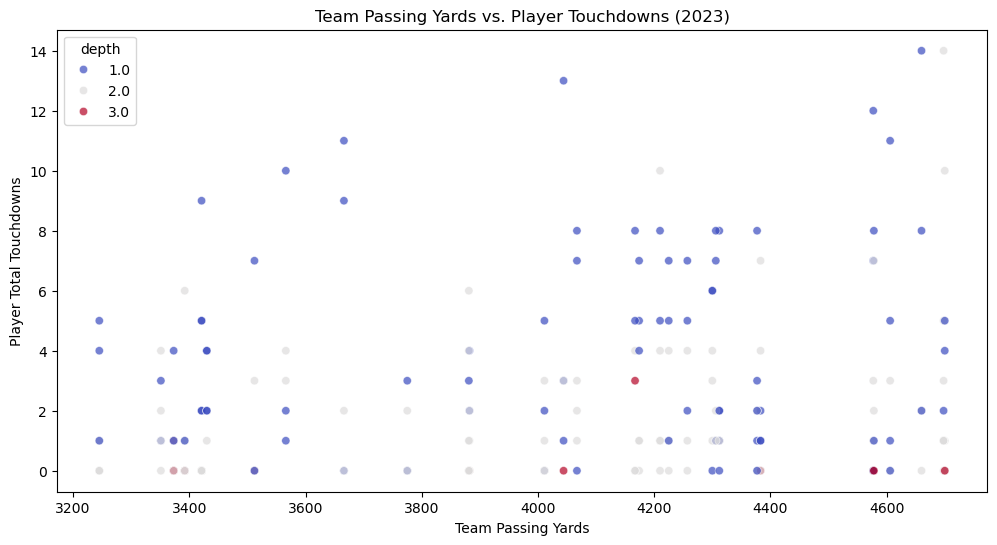

In [71]:
# Get the latest season from df_player
latest_season = df_player['season'].max()

# Filter df_player by latest season
df_player_latest = df_player[df_player['season'] == latest_season]
#print(df_player_latest.head())

# Get most recent passing yards for each team
df_team_latest = df_team.sort_values("season", ascending=False).drop_duplicates("team")
#print(df_team_latest.head())

plt.figure(figsize=(12,6))
sns.scatterplot(
    x=df_player_latest['team'].map(df_team_latest.set_index('team')['passing_yards']),  
    y=df_player_latest['total_tds'],  
    hue=df_player_latest['depth'],  
    palette='coolwarm',  
    alpha=0.7
)

plt.title(f"Team Passing Yards vs. Player Touchdowns ({latest_season})")
plt.xlabel("Team Passing Yards")
plt.ylabel("Player Total Touchdowns")
plt.show()




Here we have a scatterplot that shows player total touchdowns relative to team pass yards for the last season (2023). We use player depth as a distinguishing factor, which makes this potentially valuable information for predicting undervalued players potential.